In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [27]:
ANGLES_PATH = r"C:\Users\brend\Downloads\joint_angles.csv"
LANDMARKS_PATH = r"C:\Users\brend\Downloads\landmarks.csv"
META_PATH = r"C:\Users\brend\Downloads\metadata.csv"

angles = pd.read_csv(ANGLES_PATH)
landmarks = pd.read_csv(LANDMARKS_PATH)
meta = pd.read_csv(META_PATH)

In [35]:
def interpolate_at_event(df, value_cols, time_col="time", event_col="BR_time"):
    # Inserts kinematic values at ball release to remove discretization bias

    rows = []
    for sp, g in df.groupby("session_pitch"):
        g = g.sort_values(time_col)
        t_event = g[event_col].iloc[0]

        out = {"session_pitch": sp}
        for col in value_cols:
            out[col] = np.interp(t_event, g[time_col], g[col])

        rows.append(out)

    return pd.DataFrame(rows)


def attach_session(df):
   # Attaches pitcher/session ID
    return df.merge(
        meta[["session_pitch", "session"]],
        on="session_pitch",
        how="left"
    )


def compute_release_dispersion(df, coord_cols):
    # Spatial release dispersion relative to mean release point

    centered = df[coord_cols] - df[coord_cols].mean()
    return np.sqrt((centered ** 2).sum(axis=1)).mean()

In [34]:
trunk_cols = [
    "torso_angle_x",  # Extension
    "torso_angle_y",  # Lateral tilt
    "torso_angle_z"   # Axial rotation
]

trunk_br = interpolate_at_event(angles, trunk_cols)
trunk_br = attach_session(trunk_br)

trunk_var = (
    trunk_br
    .groupby("session")[trunk_cols]
    .std()
    .reset_index()
)

trunk_var["trunk_instability"] = np.sqrt(
    trunk_var["torso_angle_x"]**2 +
    trunk_var["torso_angle_y"]**2 +
    trunk_var["torso_angle_z"]**2
)

In [30]:
release_cols = [
    "hand_jc_x",
    "hand_jc_y",
    "hand_jc_z"
]

release_br = interpolate_at_event(landmarks, release_cols)
release_br = attach_session(release_br)

release_dispersion = (
    release_br
    .groupby("session")
    .apply(lambda x: compute_release_dispersion(x, release_cols))
    .reset_index(name="release_dispersion")
)

C:\Users\brend\AppData\Local\Temp\ipykernel_20240\3655252122.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: compute_release_dispersion(x, release_cols))


In [31]:
analysis_df = trunk_var.merge(
    release_dispersion,
    on="session"
)

pitch_counts = trunk_br.groupby("session").size()
valid_sessions = pitch_counts[pitch_counts >= 5].index

analysis_df = analysis_df[
    analysis_df["session"].isin(valid_sessions)
]

In [32]:
x = analysis_df["trunk_instability"]
y = analysis_df["release_dispersion"]

correlation = x.corr(y)
print(f"\nCorrelation (Trunk Instability vs Release Consistency): r = {correlation:.3f}")

slope, intercept, r_value, p_value, std_err = linregress(x, y)

ci_low = slope - 1.96 * std_err
ci_high = slope + 1.96 * std_err

print(f"Slope: {slope:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"r = {r_value:.3f}, p = {p_value:.4f}")
print(f"95% CI for slope: [{ci_low:.6f}, {ci_high:.6f}]")


Correlation (Trunk Instability vs Release Consistency): r = 0.457
Slope: 0.005670
Intercept: 0.026972
r = 0.457, p = 0.0007
95% CI for slope: [0.002610, 0.008731]


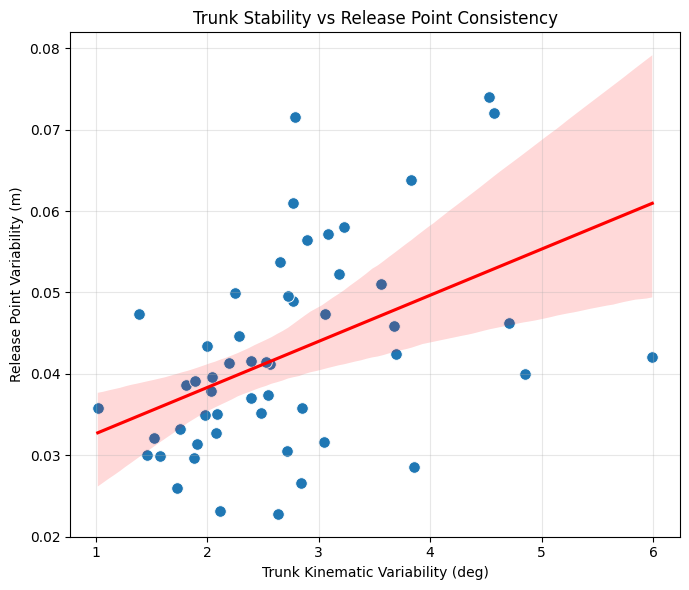

In [33]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=analysis_df,
    x="trunk_instability",
    y="release_dispersion",
    s=70
)

sns.regplot(
    data=analysis_df,
    x="trunk_instability",
    y="release_dispersion",
    scatter=False,
    color="red"
)

plt.xlabel("Trunk Kinematic Variability (deg)")
plt.ylabel("Release Point Variability (m)")
plt.title("Trunk Stability vs Release Point Consistency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()